# Getting started with AudioSeal

This notebook shows a minimal example to get started with AudioSeal. Make sure you install the package from PyPi or from source in editable mode beforehand.

First, let's prepare some example audios into the proper Tensor format using Torchaudio

In [2]:
%%capture

# For the demonstration, we need torchaudio and matplotlib to process example audios and visualize the spectrogram
import sys
!{sys.executable} -m pip install torchaudio soundfile matplotlib

In [3]:
import torch
import torchaudio
import urllib

## Generator

To watermark an audio, we simply load the watermarking generator from the hub:

In [4]:
import sys
sys.path.append("..")  # 添加上一级目录
from src.audioseal import AudioSeal

model = AudioSeal.load_generator("audioseal_wm_16bits")

### Watermarking with a secret message:

AudioSeal uses a secret message to generate a watermarking, which consists of <i>n</i> binary bits (n=16 for the above model, hence the model name). By default, if the user does not specify these n bits, a random message will be generated. This can be customized either by assigning the secret message before the watermarking process:

```
`model.message = <n bit Tensor>`
``` 

or by executing the model each time with one explicit secret message:

```
watermark = model(audio, message=<message>)
```

In [5]:
# watermarked_audio = model(audios, sample_rate=sr, message=secret_mesage, alpha=1)

In [8]:
import os
secret_dir = './my_secret_50'
acc = []
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

data_path = './audio_seal_50'
my_seal_audio = os.listdir(data_path)

for i in my_seal_audio:
    wav, sr = torchaudio.load(f'{data_path}/{i}')

    secret_mesage = torch.load(f'./{secret_dir}/{i.split("_")[-1]}_msg_tensor.pt')
    result, message = detector.detect_watermark(wav.unsqueeze(0), sample_rate=sr, message_threshold=0.5)
    acc.append(result)

acc

/tmp/ipykernel_45925/104206490.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  secret_mesage = torch.load(f'./{secret_dir}/{i.split("_")[-1]}_msg_tensor.pt')


[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9997252821922302,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [10]:
import os
acc = []
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

data_path = './audioseal_diffusion_increase_50'
my_seal_audio = os.listdir(data_path)

for i in my_seal_audio:
    wav, sr = torchaudio.load(f'{data_path}/{i}')

    secret_mesage = torch.load(f'./{secret_dir}/{i.split("_")[-1]}_msg_tensor.pt')
    result, message = detector.detect_watermark(wav.unsqueeze(0), sample_rate=sr, message_threshold=0.5)
    acc.append(result)

acc

/tmp/ipykernel_45925/3171191297.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  secret_mesage = torch.load(f'./{secret_dir}/{i.split("_")[-1]}_msg_tensor.pt')


[0.3662302494049072,
 0.32994526624679565,
 0.25192397832870483,
 0.44967636466026306,
 0.3831200897693634,
 0.41239696741104126,
 0.350247323513031,
 0.4739583432674408,
 0.347533255815506,
 0.4092864394187927,
 0.3554868996143341,
 0.35053637623786926,
 0.5525470972061157,
 0.3763186037540436,
 0.44910359382629395,
 0.49616697430610657,
 0.4139019548892975,
 0.3988320827484131,
 0.38700851798057556,
 0.3607460856437683,
 0.299834281206131,
 0.5971009135246277,
 0.3227923512458801,
 0.37030029296875,
 0.3219400942325592,
 0.3535730242729187,
 0.4186550974845886,
 0.4081798791885376,
 0.47585198283195496,
 0.3957178294658661,
 0.4747651517391205,
 0.2812750041484833,
 0.33171841502189636,
 0.6260978579521179,
 0.3730359673500061,
 0.34835806488990784,
 0.3614690601825714,
 0.5182291865348816,
 0.41785702109336853,
 0.48790377378463745,
 0.45878708362579346,
 0.3072594404220581,
 0.4095403850078583,
 0.43459364771842957,
 0.49432969093322754,
 0.2675102949142456,
 0.461733341217041,
 0.

In [11]:
sum(acc)/50

0.4069536179304123

## Detector

To detect the watermarks from an audio, we load the separate detector model and can do one of the following:

### Basic usage: Call `detect_watermark()`
This results in a tuple of form `Tuple(float, Tensor)`, where the first value indicates the probability of the audio being watermarked (the higher, the more likely), and the second value is the decoded message that is embeded by the generator. If the audio is unwatermarked (low first value), the decoded message will be just some random bits.

Note that due to the stochastic nature of the detector, the decoded message and the secret message might miss by 1 bit, so depending on the user's need, the detection might be called multiple times to get an averaged decoded message.

In [ ]:
detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

result, message = detector.detect_watermark(watermarked_audio, sample_rate=sr, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")

# Run on an unwatermarked audio
result2, message2 = detector.detect_watermark(audios, sample_rate=sr, message_threshold=0.5)
print(f"This is likely an unwatermarked audio: {result2}")


Downloading: "https://huggingface.co/facebook/audioseal/resolve/main/detector_base.pth" to /home/binhaoma/.cache/audioseal/94c8df0b1d5ea8e45af4c884
100%|██████████| 33.1M/33.1M [00:00<00:00, 87.0MB/s]



This is likely a watermarked audio: 1.0
This is likely an unwatermarked audio: 3.296440627309494e-05


In [ ]:
message

tensor([[1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.int32)

`message_threshold` indicates the threshold in which the detector will convert the stochastic messages (with probability between 0 and 1) into the n-bit binary format. In most of the case, the generator generates an unbiased message from the secret, so `0.5` is a reasonable choice (so in the above example, value > 0.5 means 1 and value < 0.5 means 0). 


#### Advanced usage: Call `forward()`

The detector can also be called directly as a Torch module. This will return 2 tensors: 
- The first tensor of size `batch x 2 x frames` indicates the probability of each frame being watermarked (positive or negative). So t[:, 0, :] corresponds to the negative probability and t[:, 1, :] corresponds to the positive probability
- The second tensor of size `batch x n_bits` corresponds to the message detected from the audio. It indicates the probability for each bit to be 1. In case of unwatermarked audios, this tensor is random

In [ ]:
pred_prob, message_prob = detector(watermarked_audio, sample_rate=sr)
pred_prob[:, 1, :]

tensor([[0.9999, 0.9999, 0.9999,  ..., 0.9944, 0.9943, 0.9942]],
       grad_fn=<SliceBackward0>)

In [ ]:
message_prob

tensor([[0.7580, 0.7574, 0.7810, 0.2272, 0.7667, 0.2012, 0.8021, 0.2266, 0.2805,
         0.2240, 0.7478, 0.7594, 0.2699, 0.1927, 0.8195, 0.2720]],
       grad_fn=<SigmoidBackward0>)

### Robustness against attacks

We can evaluate the robustness of the detector against some attacks. For this purpose, we will perform some simple attacks: Pink noise, highpass filter, compression in different formats. For the full list of attacks, please refer to our paper. 


#### Pink noise attack

In [ ]:
from attacks import AudioEffects as af

pink_noised_audio = af.pink_noise(watermarked_audio, noise_std=0.2)

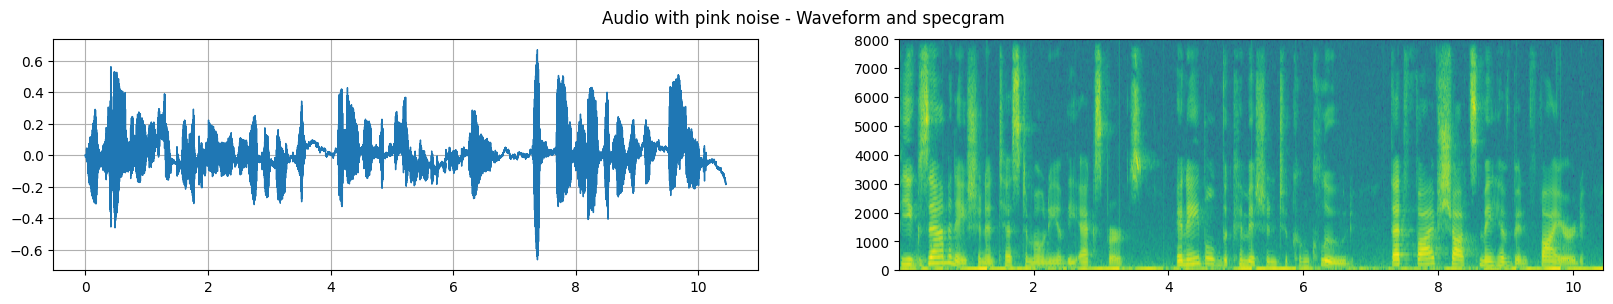

In [ ]:
plot_waveform_and_specgram(pink_noised_audio, sample_rate=16000, title="Audio with pink noise")

In [ ]:
result, message = detector.detect_watermark(pink_noised_audio, sample_rate=sr)
print(f"Detection Result with Pink Noise: {result}")

Detection Result with Pink Noise: 0.8675737380981445


#### Lowpass filter

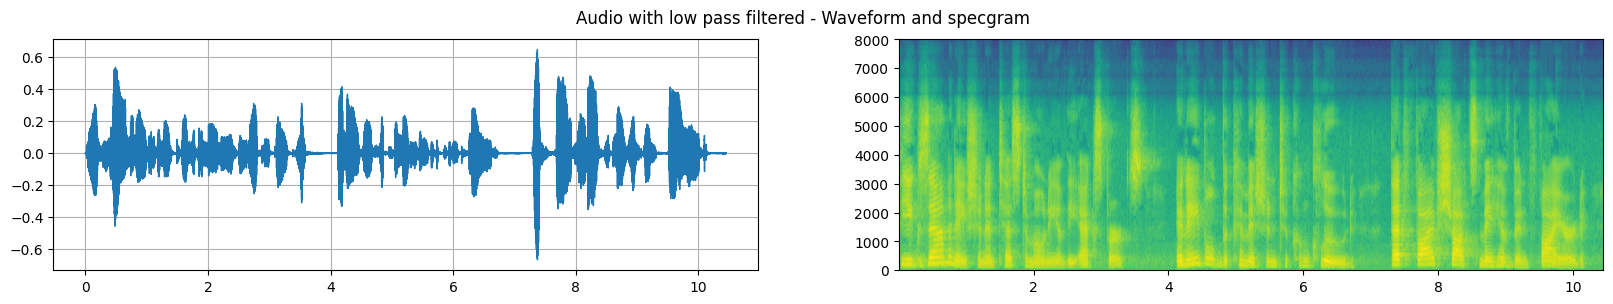

In [ ]:
lowpass_filtered = af.lowpass_filter(watermarked_audio, cutoff_freq=5000, sample_rate=16000)
plot_waveform_and_specgram(lowpass_filtered, sample_rate=16000, title="Audio with low pass filtered")

In [ ]:
result, message = detector.detect_watermark(lowpass_filtered, sample_rate=sr)
print(f"Detection Result with Lowpass Filter: {result}")

Detection Result with Lowpass Filter: 1.0
